In [1]:
import os
import random
import time
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)


print("Libraries loaded")
print("Seed fixed:", SEED)

Libraries loaded
Seed fixed: 42


In [2]:
train_data = pd.read_csv(
    r"../datasets/CICIDS2017/train_test/CICIDS2017_Train_80.csv"
)


test_data = pd.read_csv(
    r"../datasets/CICIDS2017/train_test/CICIDS2017_Test_20.csv"
)


print("Train shape:", train_data.shape)
print("Test shape :", test_data.shape)

Train shape: (1948553, 41)
Test shape : (487139, 41)


In [3]:
X_train = train_data.drop(
    "label",
    axis=1
)


X_test = test_data.drop(
    "label",
    axis=1
)


y_train = train_data["label"]

y_test = test_data["label"]


print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1948553, 40)
X_test : (487139, 40)
y_train: (1948553,)
y_test : (487139,)


In [4]:
from sklearn.utils.class_weight import compute_sample_weight


sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)


print(sample_weights[:10])

[ 0.09742707  1.07844812  0.09742707  0.09742707  0.09742707 25.36121668
  1.8173342   0.09742707  0.50080909  0.09742707]


In [5]:
xgb_model = XGBClassifier(

    n_estimators=200,

    max_depth=8,

    learning_rate=0.1,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="multi:softmax",

    num_class=14,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=SEED,

    n_jobs=-1

)


print(xgb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1, num_class=14, ...)


In [6]:


xgb_model.fit(

    X_train,

    y_train,

    sample_weight=sample_weights

)
y_pred = xgb_model.predict(
    X_test
)


In [7]:
accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9990618694048311
Precision: 0.9992378180676281
Recall   : 0.9990618694048311
F1 Score : 0.9991243947091389


In [8]:
print(

    classification_report(

        y_test,

        y_pred,

        digits=4

    )

)

              precision    recall  f1-score   support

           0     0.9999    0.9991    0.9995    357145
           1     0.9982    1.0000    0.9991      1102
           2     0.9998    1.0000    0.9999     19147
           3     0.9818    1.0000    0.9908      1673
           4     0.9999    0.9996    0.9998     69479
           5     0.9863    0.9949    0.9906      1372
           6     0.9819    0.9961    0.9890      1035
           7     1.0000    1.0000    1.0000      1906
           8     1.0000    1.0000    1.0000         2
           9     0.9998    0.9998    0.9998     32265
          10     0.9975    1.0000    0.9987      1190
          11     0.7023    0.8885    0.7845       547
          12     1.0000    0.6000    0.7500         5
          13     0.6257    0.8819    0.7320       271

    accuracy                         0.9991    487139
   macro avg     0.9481    0.9543    0.9453    487139
weighted avg     0.9992    0.9991    0.9991    487139



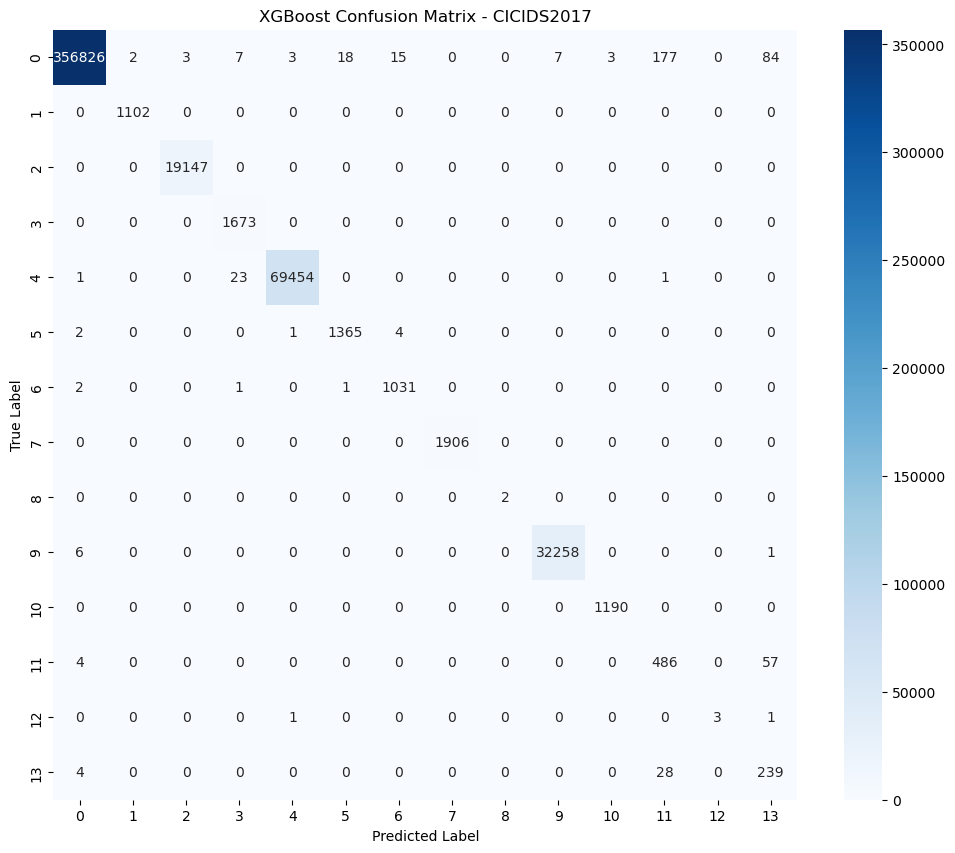

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(
    figsize=(12,10)
)


sns.heatmap(

    cm,

    cmap="Blues",
    annot=True,

    fmt="d"

)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


plt.title(
    "XGBoost Confusion Matrix - CICIDS2017"
)


plt.show()

In [10]:
joblib.dump(

    xgb_model,

    "XGBoost_CICIDS2017.pkl"

)


print("XGBoost model saved")

XGBoost model saved


In [11]:
xgb_results = pd.DataFrame({

    "Model": [
        "XGBoost"
    ],

    "Accuracy": [
        accuracy
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1_Score": [
        f1
    ],

   

})


xgb_results.to_csv(
    "XGBoost_results.csv",
    index=False
)


print(xgb_results)

     Model  Accuracy  Precision    Recall  F1_Score
0  XGBoost  0.999062   0.999238  0.999062  0.999124


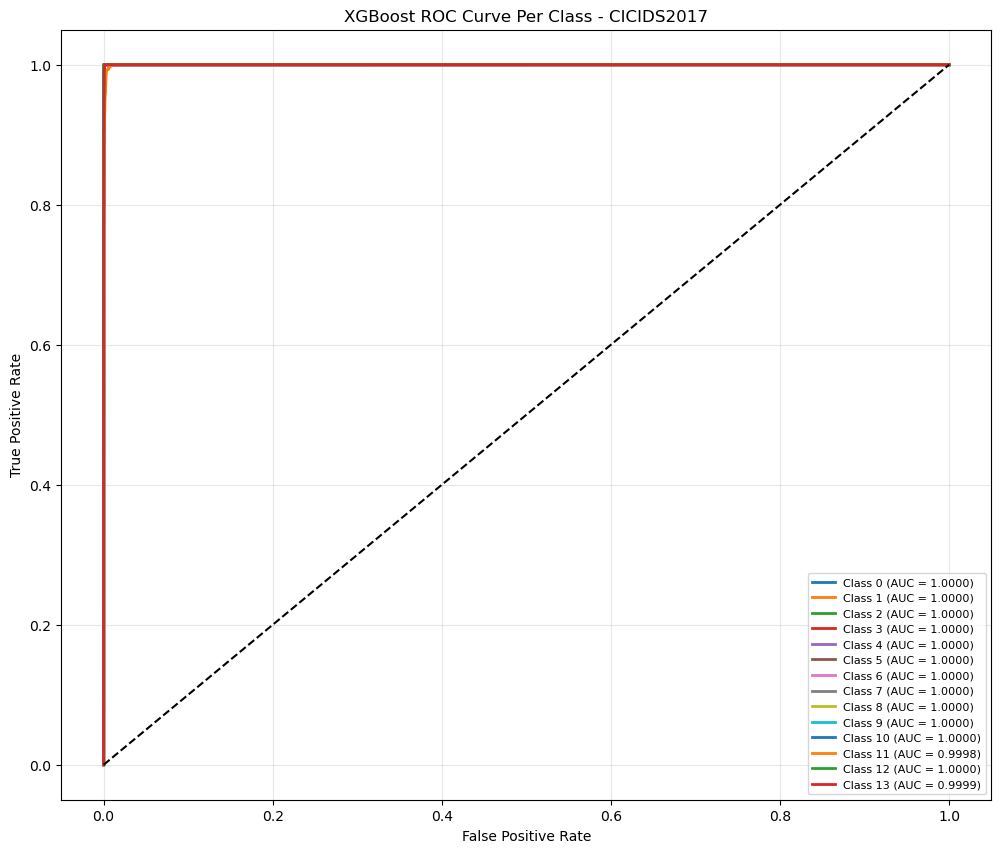

In [13]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Probability prediction
y_score = xgb_model.predict_proba(X_test)

# Binarize test labels
classes = np.unique(y_test)
y_test_bin = label_binarize(
    y_test,
    classes=classes
)

n_classes = len(classes)

# Calculate ROC for each class
plt.figure(figsize=(12, 10))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.4f})"
    )

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    "k--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve Per Class - CICIDS2017")

plt.legend(
    loc="lower right",
    fontsize=8
)

plt.grid(alpha=0.3)
plt.show()